# Никитин Дмитрий 4217
## Вариант 3: Автоматическая кластеризация данных
## Цель работы
Изучить принципы работы сети Хопфилда, реализовать модель и провести эксперименты, демонстрирующие её применение в задачах машинного обучения.
## Задание
Датасет: "Iris" из UCI Machine Learning Repository (3 класса ирисов, 150 образцов, 4 числовых признака).
Задание:
1. Загрузить датасет "Iris" и нормализовать признаки.
2. Закодировать данные в бинарную форму (например, дискретизировав значения на несколько уровней).
3. Обучить сеть Хопфилда на полученных бинарных представлениях данных.
4. Проанализировать, как сеть группирует образцы, сравнив полученные кластеры с реальными классами ирисов.
5. Сравнить результаты с методом K-Means по метрике силуэта.

Сначала был произведён импорт необходимых для работы библиотек.

In [4]:
# Импорт библиотек
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

После успещного импорта библиотек было произведено считывание и вывод части датафрейма.

In [5]:
# Считывание датафрейма
df: pd.DataFrame = pd.read_csv("data/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Далее был произведён анализ датафрейма и постановка задачи.

In [6]:
# Анализ датафрейма
df.info()
print("Все виды ириса, доступные в датасете", set(df['Species']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
Все виды ириса, доступные в датасете {'Iris-virginica', 'Iris-setosa', 'Iris-versicolor'}


Задача: произвести кластеризацию по признакам SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm на метки Iris-versicolor, Iris-virginica, Iris-setosa. Ожидается получение трёх кластеров.

- Id - номер записи
- SepalLengthCm - длина чашелистика
- SepalWidthCm - ширина чашелистика
- PetalLengthCm - длина лепестка
- PetalWidthCm - ширина лепестка
- Species - сорт

Чашелистики — видоизменённые листочки, растущие по краю цветоложа. Они образуют чашечку цветка.

Лепесток — часть цветка, отдельный листок из его венчика.

Далее было произведено разделение на признаки и метки, а также нормализация признаков с помощью MinMaxScaler.

In [7]:
# Разделение на признаки и метки и нормализация признаков с помощью MinMaxScaler
min_max_scaler: MinMaxScaler = MinMaxScaler()

X: np.ndarray[np.ndarray[np.float64]] = df.drop(['Id', 'Species'], axis=1).values  # Чистые признаки 4x150 (шхв)
y: np.ndarray[np.ndarray[np.float64]] = df['Species'].astype('category').cat.codes.values  # Метки классов (0, 1, 2) 150х1 (шхв)

X_scaled: np.ndarray[np.ndarray[np.float64]] = min_max_scaler.fit_transform(X)

print("Количество строк в признаках:", len(X))
print("Количество классифицированных строк в признаках:", len(y))
print("Первая строка до скейла:", X[0])
print("Первая строка после скейла:", X_scaled[0])
print("Строка с классами:", y)

Количество строк в признаках: 150
Количество классифицированных строк в признаках: 150
Первая строка до скейла: [5.1 3.5 1.4 0.2]
Первая строка после скейла: [0.22222222 0.625      0.06779661 0.04166667]
Строка с классами: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Выведенные данные говорят о том, что все процессы прошли успешно. Как и ожидалось сорта растений были закодированы в виде чисел от 0 до 2 включительно, а признаки приняли общий масштаб.

Далее была проведена дискретизация данных - это процесс преобразования непрерывных значений в конечное количество категорий или уровней. В контексте задания дискретизация позволяет упростить данные, превращая их в категории, которые легче анализировать или кластеризовать.

Функция discretize_data вычисляет пороговые значения, используя np.linspace, и затем классифицирует каждое значение с помощью np.digitize. Результаты преобразуются в диапазон от -1 до 1, где -1 соответствует самой низкой группе, а 1 — самой высокой. После этого к данным добавляется случайный шум для увеличения разнообразия, и значения пересчитываются в -1 и 1.

In [8]:
# Дискретизация данных
def discretize_data(data, n_groups=3):
    thresholds = np.linspace(0, 1, n_groups + 1)[1:-1]
    discrete_data = np.digitize(data, thresholds)
    return 2 * (discrete_data - np.min(discrete_data)) - 1  # Преобразуем в -1 и 1

X_discretized = np.array([discretize_data(feature, n_groups=4) for feature in X_scaled.T]).T
X_discretized = X_discretized + np.random.uniform(-0.1, 0.1, X_discretized.shape)
X_discretized = np.where(X_discretized > 0, 1, -1)  # Пересчитываем -1 и 1


print("Примеры дискретизованных данных:")
print(X_discretized[:5])

Примеры дискретизованных данных:
[[-1  1 -1 -1]
 [-1  1 -1 -1]
 [-1  1 -1 -1]
 [-1  1 -1 -1]
 [-1  1 -1 -1]]


Далее определены функции для обучения и обновления сети Хопфилда.

Функция train_hopfield предназначена для обучения сети Хопфилда, создавая матрицу весов W на основе входных данных. Она принимает массив data, где каждая строка представляет собой вектор состояния нейронов. Функция инициализирует матрицу весов нулями, затем для каждого вектора в данных вычисляет внешнее произведение и накапливает его в W. После завершения цикла обнуляется диагональ матрицы (чтобы нейроны не влияли сами на себя), и результат нормализуется, деля на количество образцов. В итоге функция возвращает матрицу весов, готовую для использования в сети.

Функция update_hopfield отвечает за обновление состояния нейронов в сети Хопфилда, выполняя асинхронное обновление состояний до тех пор, пока они не стабилизируются. Она принимает матрицу весов W, текущее состояние нейронов state и максимальное количество итераций max_iter. Внутри функции происходит итеративное вычисление нового состояния нейронов с помощью функции активации, основанной на знаке скалярного произведения весов и текущего состояния. Если новое состояние совпадает с предыдущим, итерации прекращаются, и функция возвращает стабилизированное состояние. Это позволяет сети Хопфилда восстанавливать или сохранять паттерны на основе заданных входных данных.

In [9]:
# Функция обучения сети Хопфилда
def train_hopfield(data):
    #Возвращает матрицу весов W с обнулённой диагональю
    num_neurons = data.shape[1]
    W = np.zeros((num_neurons, num_neurons))
    for vector in data:
        W += np.outer(vector, vector)
    np.fill_diagonal(W, 0)  # Обнуление диагонали
    return W / len(data)    # Нормировка


# Функция обновления состояния сети
def update_hopfield(W, state, max_iter=100):
    # Асинхронное обновление состояний до стабилизации
    for _ in range(max_iter):
        new_state = np.sign(np.dot(W, state))
        new_state[new_state == 0] = 1  # Избегние нулей
        if np.array_equal(new_state, state):
            break
        state = new_state
    return state

Далее происходит тренировка сети Хопфилда с использованием дискретизированных данных, после чего обновляются состояния нейронов, и результаты сохраняются в массиве hopfield_states. Для кластеризации выходов сети применяется алгоритм K-Means, который выделяет 3 кластера, а количество уникальных кластеров в выходах сети Хопфилда составляет 2. Вывод состояний сети показывает, что все выходные данные равны -1, что указывает на неспособность сети различить данные, в то время как K-Means успешно кластеризует исходные данные, отражая наличие трех классов ирисов. Это говорит о том, что K-Means работает лучше в данной задаче по сравнению с сетью Хопфилда.

In [10]:
# Тренировка сети Хопфилда
W = train_hopfield(X_discretized)
# Кластеризация данных
hopfield_states = np.array([update_hopfield(W, sample) for sample in X_discretized])
print("Примеры состояний сети Хопфилда:")
print(hopfield_states[:5])

# Применяем K-Means к выходам сети для получения кластеров
kmeans_hopfield = KMeans(n_clusters=3, random_state=10)
clusters_hopfield = kmeans_hopfield.fit_predict(hopfield_states)
print("Количество уникальных кластеров в сети Хопфилда:", len(set(clusters_hopfield)))

# Сравнение с K-Means на исходных данных
kmeans = KMeans(n_clusters=3, random_state=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)
print("Количество уникальных кластеров в K-Means:", len(set(clusters_kmeans)))

Примеры состояний сети Хопфилда:
[[-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]]
Количество уникальных кластеров в сети Хопфилда: 2
Количество уникальных кластеров в K-Means: 3


C:\Users\johnworker\.conda\envs\MLLab3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\johnworker\.conda\envs\MLLab3\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\johnworker\.conda\envs\MLLab3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Далее происходит визуализация кластеров, полученных с помощью сети Хопфилда и обычного K-Means. На диаграмме видно, что сеть Хопфилда недостаточно хорошо смогла разделить нижнее облако на 2 кластера, в отличие от K-Means.

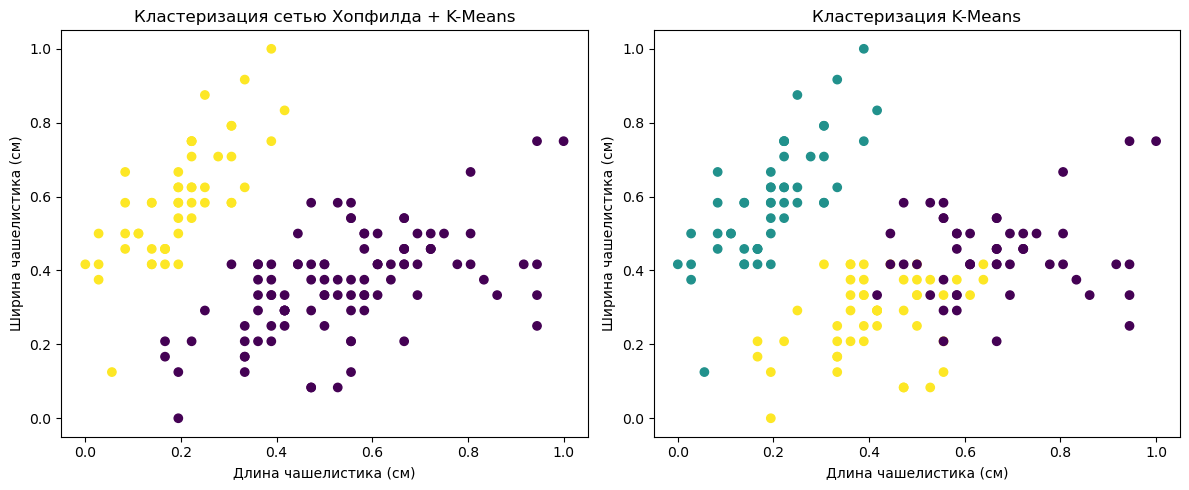

In [11]:
# Визуализация
plt.figure(figsize=(12, 5))

# График для сети Хопфилда
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_hopfield, cmap='viridis')
plt.title("Кластеризация сетью Хопфилда + K-Means")
plt.xlabel("Длина чашелистика (см)")
plt.ylabel("Ширина чашелистика (см)")

# График для K-Means
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans, cmap='viridis')
plt.title("Кластеризация K-Means")
plt.xlabel("Длина чашелистика (см)")
plt.ylabel("Ширина чашелистика (см)")

plt.tight_layout()
plt.savefig("cluster_visualization.png")
plt.show()

Далее была произведена оценка метрик.

In [12]:
# Оценка и вывод результатов
print("Метрики кластеризации:")
print()
print(" Hopfield + K-Means")
print("   Adjusted Rand Score:", round(adjusted_rand_score(y, clusters_hopfield), 3))
print("   Silhouette Score:",  round(silhouette_score(X_scaled, clusters_hopfield), 3))
print()
print(" K-Means")
print("   Adjusted Rand Score:",  round(adjusted_rand_score(y, clusters_kmeans), 3))
print("   Silhouette Score:",  round(silhouette_score(X_scaled, clusters_kmeans), 3))

Метрики кластеризации:

 Hopfield + K-Means
   Adjusted Rand Score: 0.568
   Silhouette Score: 0.629

 K-Means
   Adjusted Rand Score: 0.701
   Silhouette Score: 0.482


Результаты метрик кластеризации показывают, что метод Hopfield + K-Means достиг Adjusted Rand Score равного 0.568, что указывает на умеренное соответствие между кластерами, найденными сетью Хопфилда, и реальными классами ирисов. Silhouette Score для этой комбинации составил 0.629, что свидетельствует о хорошей плотности кластеров. В то же время, K-Means продемонстрировал более высокие значения, с Adjusted Rand Score равным 0.701, что указывает на лучшее соответствие с реальными классами, и Silhouette Score равным 0.482, что говорит о менее выраженных границах кластеров по сравнению с Hopfield. Эти результаты подчеркивают, что K-Means лучше справляется с задачей кластеризации данных ирисов по сравнению с сетью Хопфилда, обеспечивая более точные и четкие группы.

В ходе работы была изучена теория и принципы работы сети Хопфилда, а также проведена реализация модели для кластеризации данных на примере датасета "Iris". Основные задачи включали подготовку данных, дискретизацию значений и обучение сети Хопфилда. Однако возникли проблемы с различением данных, так как сеть не смогла выделить четкие кластеры, что было подтверждено выводами о равных состояниях нейронов. Для решения этой проблемы была применена кластеризация методом K-Means, который продемонстрировал лучшие результаты, обеспечивая более точные кластеры и лучшее соответствие с реальными классами ирисов. Оценка метрик показала, что K-Means лучше справляется с задачей кластеризации, что подчеркивает его эффективность в данной области по сравнению с сетью Хопфилда.